# 🧬 SARS-CoV-2 Spike Protein Inhibitor Analysis
**Dimple Srivastava | Jamia Hamdard, Department of Virology**

**Dissertation:** In Silico Identification of Potential SARS-CoV-2 Spike Protein Inhibitors Using Molecular Docking

**Targets:** 6M0J — Spike RBD | 6VXX — Whole Spike | 7DWZ — S2 Fusion Domain

**Dataset:** 85 compounds | 3 protein targets | SDF structure files


## Step 1 — Import Libraries

In [1]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os
from IPython.display import display
print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## Step 2 — Name Mapping (CSV names → SDF filenames)

In [2]:
name_to_sdf = {
    'Abemaciclib':                 'abemaciclib',
    'Afzelechin':                  'afzelechin',
    'Amprenavir':                  'amprenavir',
    'Andrographolide':             'andrographolide',
    'Angeloylgomisin O':           'angeloylgomisin_o',
    'Aspirin':                     'aspirin',
    'Atorvastatin':                'atorvastatin',
    'Azithromycin':                'azithromycin',
    'Brazilin':                    'brazilin',
    'C8.2':                        'C8.2',
    'CKP-25':                      'ckp25',
    'Calpeptin':                   'calpeptin',
    'Camostat':                    'camostat',
    'Cannabigerovarinic acid':      'cannabigerovarinic_acid',
    'Cannabinolic acid':            'cannabinolic_acid',
    'Catechin gallate':             'catechin_gallate',
    'Celecoxib':                   'celecoxib',
    'Cetirizine':                  'cetirizine',
    'Chloroquine':                 'chloroquine',
    'Chlorpromazine':              'chlorpromazine',
    'Chrysosplenetin':             'chrysosplenetin',
    'Clarithromycin':              'clarithromycin',
    'Clemastine':                  'clemastine',
    'Clofazimine':                 'clofazimine',
    'Corylifol A':                 'corylifol_a',
    'Curcumin':                    'curcumin',
    'Dactinomycin':                'dactinomycin',
    'Digoxin':                     'digoxin',
    'Dihydrokaempferol':           'dihydrokaempferol',
    'Diphenhydramine':             'diphenhydramine',
    'Dolutegravir':                'dolutegravir',
    'Doxycycline':                 'doxycycline',
    'ECGC':                        'egcg',
    'Emodin':                      'emodin',
    'Erythrodiol':                 'erythrodiol',
    'Erythromycin':                'erythromycin',
    'Etravirine':                  'etravirine',
    'Fagaronine':                  'fagaronine',
    'Favipiravir':                 'favipiravir',
    'Ferulic acid':                'ferulic_acid',
    'Hesperidin':                  'hesperetin',
    'Ibuprofen':                   'ibuprofen',
    'Ilimaquinone':                'ilimaquinone',
    'Indomethacin':                'indomethacin',
    'Isorhamnetin':                'isorhamnetin',
    'Kaempferol':                  'kaempferol',
    'Linezolid':                   'linezolid',
    'Loratadine':                  'loratadine',
    'Lovastatin':                  'lovastatin',
    'Lumacaftor':                  'lumacaftor',
    'Meloxicam':                   'meloxicam',
    'Mevastatin':                  'mevastatin',
    'Minocycline':                 'minocycline',
    'NSC281245':                   'NSC281245',
    'NSC36398':                    'NSC36398',
    'Naproxen':                    'naproxen',
    'Nelfinavir':                  'nelfinavir',
    'Niclosamide':                 'niclosamide',
    'Nimesulide':                  'nimesulide',
    'Ouabain':                     'ouabain',
    'Oxyberberine':                'oxyberberine',
    'Paracetamol':                 'paracetamol',
    'Phenyl Carbamate':            'phenyl_carbamate',
    'Pravastatin':                 'pravastatin',
    'Procyanidin':                 'procyanidin',
    'Promethazine':                'promethazine',
    'Pterostilbene':               'pterostilbene',
    'Quiniline 2 carboxylic acid': 'quiniline2carboxylic_acid',
    'Radotinib':                   'radotinib',
    'Resveratrol':                 'resveratrol',
    'Retusin':                     'retusin',
    'Rhamnocitrin':                'rhamnocitrin',
    'Rifabutin':                   'rifabutin',
    'Ritonavir':                   'ritonavir',
    'Rutaecarpine':                'rutaecarpine',
    'SSAA09E3':                    'ssaa09e3',
    'Schisandrin B':               'schisandrin_b',
    'Simvastatin':                 'simvastatin',
    'Sodium lifitegrast':          'sodium lifitegrast',
    'Theaflavin':                  'theaflavin',
    'Toremifene':                  'toremifene',
    'β-caryophyllene':             'beta_caryophyllene',
    'Rhein':                       None,
    'Rosuvastatin':                None,
}
mapped = sum(1 for v in name_to_sdf.values() if v is not None)
print(f'✅ Mapping ready: {mapped} compounds mapped to SDF files')
print(f'⚠️  No SDF: Rhein, Rosuvastatin (will be skipped)')

✅ Mapping ready: 82 compounds mapped to SDF files
⚠️  No SDF: Rhein, Rosuvastatin (will be skipped)


## Step 3 — Load results.csv

In [3]:
df_raw = pd.read_csv('results.csv')
df_raw.columns = ['Ligand', 'Binding_Energy', 'Protein']
df_raw['Ligand'] = df_raw['Ligand'].str.strip()
print(f'✅ Loaded {len(df_raw)} rows | {df_raw["Ligand"].nunique()} unique compounds')
print()
print('Compounds per protein:')
print(df_raw['Protein'].value_counts())
df_raw.head()

✅ Loaded 84 rows | 84 unique compounds

Compounds per protein:
Protein
6MOJ    42
7DWZ    26
6VXX    16
Name: count, dtype: int64


,Ligand,Binding_Energy,Protein
0,C8.2,-7.640,6MOJ
1,NSC281245,-6.337,6MOJ
2,NSC36398,-6.395,6MOJ
3,Amprenavir,-5.716,6MOJ
4,Azithromycin,-6.386,6MOJ


## Step 4 — Load SDF Files and Calculate Properties

In [4]:
SDF_FOLDER = 'corrupt'

def load_mol(sdf_name):
    if sdf_name is None: return None
    path = os.path.join(SDF_FOLDER, f'{sdf_name}.sdf')
    if not os.path.exists(path): return None
    sup = Chem.SDMolSupplier(path)
    return sup[0] if sup and len(sup) > 0 else None

def calc_props(mol):
    if mol is None: return None
    try:
        return {
            'Mol_Weight':      round(Descriptors.MolWt(mol), 2),
            'LogP':            round(Descriptors.MolLogP(mol), 2),
            'HBond_Donors':    Descriptors.NumHDonors(mol),
            'HBond_Acceptors': Descriptors.NumHAcceptors(mol),
            'Rotatable_Bonds': Descriptors.NumRotatableBonds(mol),
            'TPSA':            round(Descriptors.TPSA(mol), 2),
            'Aromatic_Rings':  Descriptors.NumAromaticRings(mol),
        }
    except: return None

results = []
skipped = []

for _, row in df_raw.iterrows():
    ligand   = row['Ligand'].strip()
    sdf_name = name_to_sdf.get(ligand)
    mol      = load_mol(sdf_name)
    props    = calc_props(mol)
    if props:
        props.update({'Ligand': ligand, 'Binding_Energy': row['Binding_Energy'], 'Protein': row['Protein']})
        results.append(props)
        print(f'✅ {ligand}')
    else:
        skipped.append(ligand)
        print(f'❌ {ligand} — skipped')

df_props = pd.DataFrame(results)[['Ligand','Protein','Binding_Energy',
    'Mol_Weight','LogP','HBond_Donors','HBond_Acceptors',
    'Rotatable_Bonds','TPSA','Aromatic_Rings']]

print(f'\n✅ Loaded: {len(results)} | ❌ Skipped: {len(skipped)}')

✅ C8.2
✅ NSC281245
✅ NSC36398
✅ Amprenavir
✅ Azithromycin
✅ Camostat
✅ Cetirizine
✅ Chloroquine
✅ Chlorpromazine
✅ CKP-25
✅ Clarithromycin
✅ Clemastine
✅ Clofazimine
✅ Dactinomycin
✅ Diphenhydramine
✅ Dolutegravir
✅ Doxycycline
✅ Erythromycin
✅ Etravirine
✅ Fagaronine
✅ Favipiravir
✅ Linezolid
✅ Loratadine
✅ Lumacaftor
✅ Minocycline
✅ Nelfinavir
✅ Niclosamide
✅ Phenyl Carbamate
✅ Promethazine
✅ Quiniline 2 carboxylic acid
✅ Radotinib
✅ Rifabutin
✅ Ritonavir
✅ Rutaecarpine
✅ Sodium lifitegrast
✅ SSAA09E3
✅ Toremifene
✅ Angeloylgomisin O
✅ Cannabigerovarinic acid
✅ Cannabinolic acid
✅ Corylifol A
✅ Theaflavin
✅ Abemaciclib
✅ Aspirin
✅ Brazilin
✅ Catechin gallate
✅ Celecoxib
✅ ECGC
✅ Hesperidin
✅ Ibuprofen
✅ Indomethacin
✅ Meloxicam
✅ Naproxen
✅ Nimesulide
✅ Paracetamol
✅ Procyanidin
✅ Pterostilbene
✅ Resveratrol
✅ Afzelechin
✅ Andrographolide
✅ Atorvastatin
✅ Chrysosplenetin
✅ Curcumin
✅ Digoxin
✅ Dihydrokaempferol
✅ Emodin
✅ Ilimaquinone
✅ Isorhamnetin
✅ Kaempferol
✅ Lovastatin
✅ Mevast

## Step 5 — Lipinski Rule of 5

In [5]:
df_props['Lipinski_Pass'] = df_props.apply(
    lambda r: r['Mol_Weight']<=500 and r['LogP']<=5 and r['HBond_Donors']<=5 and r['HBond_Acceptors']<=10, axis=1)

print('='*55)
print('LIPINSKI RESULTS PER PROTEIN')
print('='*55)
for p in sorted(df_props['Protein'].unique()):
    s  = df_props[df_props['Protein']==p]
    ok = s[s['Lipinski_Pass']==True]
    print(f'{p} → Total:{len(s):>3} | Pass:{len(ok):>3} | Fail:{len(s)-len(ok):>3}')
print(f'\nOverall → Pass: {int(df_props["Lipinski_Pass"].sum())} / {len(df_props)}')

LIPINSKI RESULTS PER PROTEIN
6MOJ → Total: 42 | Pass: 23 | Fail: 19
6VXX → Total: 16 | Pass: 12 | Fail:  4
7DWZ → Total: 24 | Pass: 20 | Fail:  4

Overall → Pass: 55 / 82


## Step 6 — Top Hits Per Protein

In [6]:
print('='*70)
print('TOP 5 DRUG-LIKE INHIBITORS PER PROTEIN TARGET')
print('='*70)
for p in sorted(df_props['Protein'].unique()):
    top = df_props[(df_props['Protein']==p)&(df_props['Lipinski_Pass']==True)].sort_values('Binding_Energy').head(5)
    print(f'\n🎯 {p}:')
    for _, r in top.iterrows():
        print(f"   {r['Ligand']:<32} {r['Binding_Energy']:>7} kcal/mol | MW:{r['Mol_Weight']:>7} | LogP:{r['LogP']:>5}")

TOP 5 DRUG-LIKE INHIBITORS PER PROTEIN TARGET

🎯 6MOJ:
   Lumacaftor                        -8.607 kcal/mol | MW: 452.41 | LogP: 4.75
   SSAA09E3                           -7.89 kcal/mol | MW: 327.34 | LogP: 3.71
   CKP-25                            -7.343 kcal/mol | MW: 288.35 | LogP: 4.25
   Dolutegravir                      -7.166 kcal/mol | MW: 419.38 | LogP: 1.35
   Rutaecarpine                       -7.02 kcal/mol | MW: 287.32 | LogP:  3.1

🎯 6VXX:
   Hesperidin                       -10.417 kcal/mol | MW: 302.28 | LogP: 2.52
   Brazilin                           -8.34 kcal/mol | MW: 286.28 | LogP: 1.61
   Celecoxib                          -8.34 kcal/mol | MW: 381.38 | LogP: 3.51
   Meloxicam                          -8.23 kcal/mol | MW: 351.41 | LogP: 1.95
   Indomethacin                      -7.844 kcal/mol | MW: 357.79 | LogP: 3.93

🎯 7DWZ:
   Oxyberberine                      -8.583 kcal/mol | MW: 351.36 | LogP: 2.97
   Mevastatin                        -8.163 kcal/mol | MW:

## Step 7 — Charts

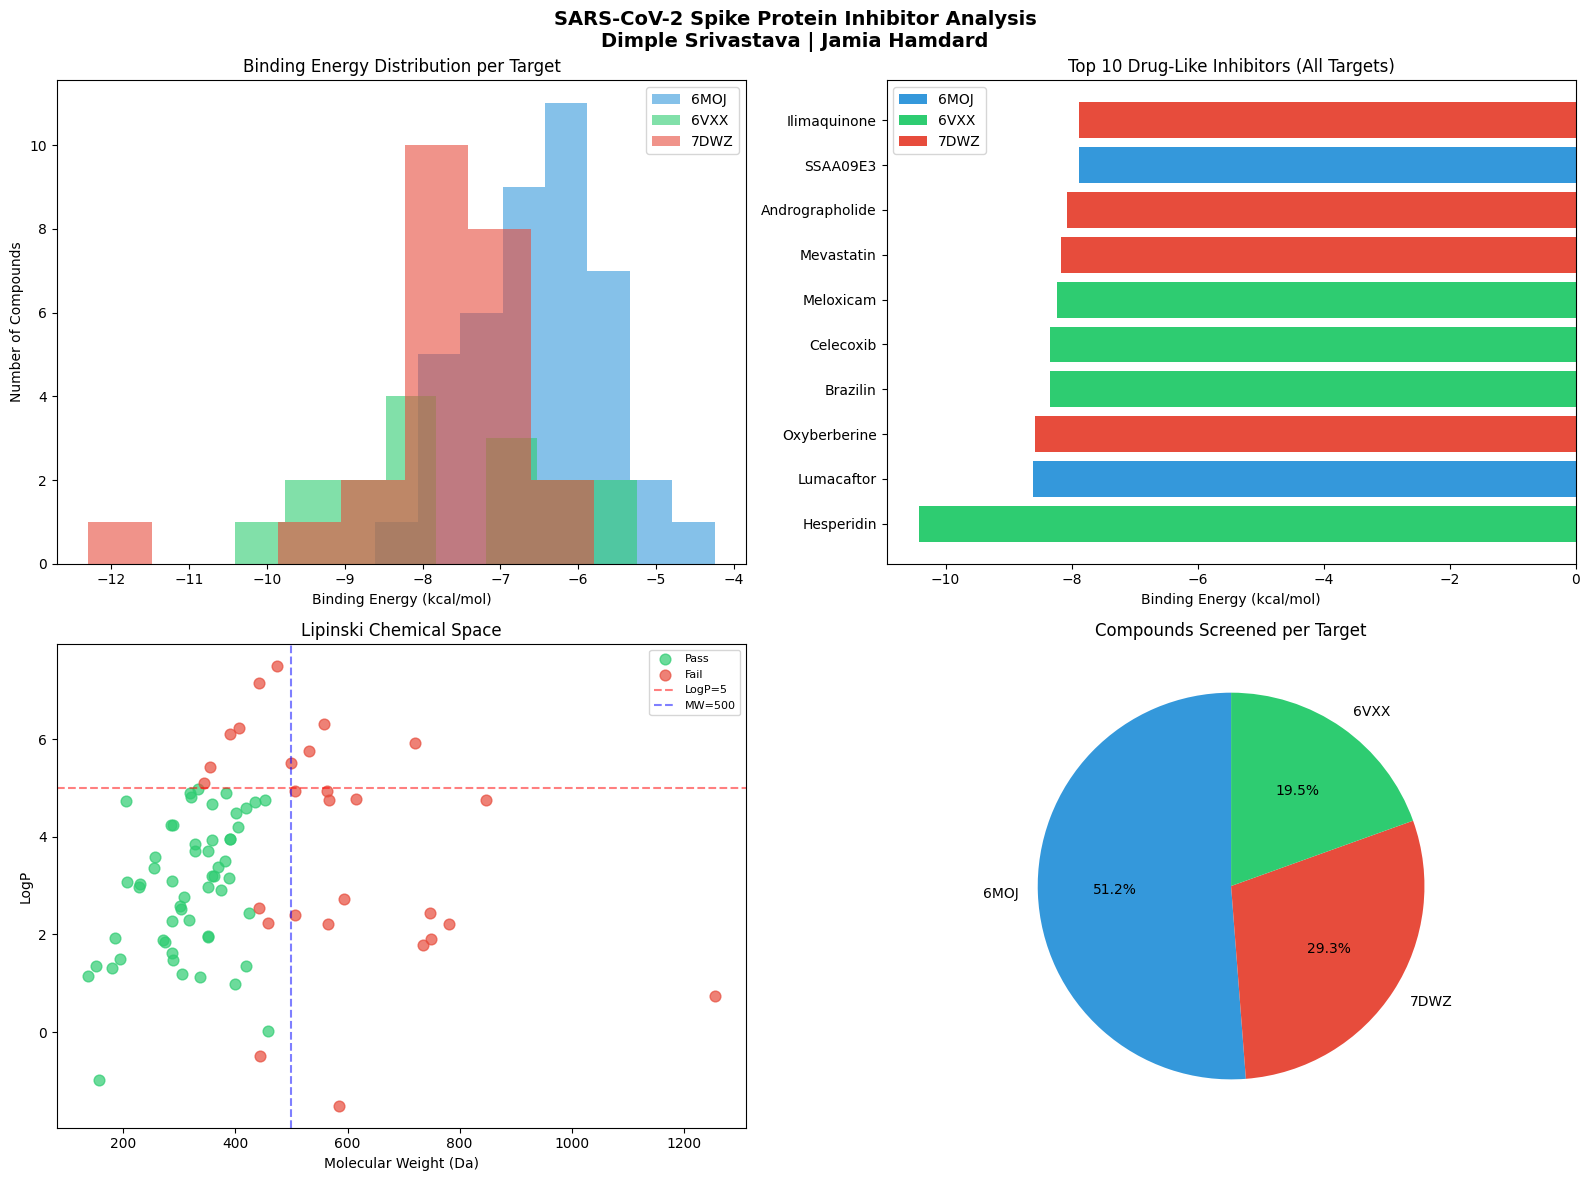

✅ Saved as sars_cov2_analysis.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SARS-CoV-2 Spike Protein Inhibitor Analysis\nDimple Srivastava | Jamia Hamdard', fontsize=14, fontweight='bold')

proteins   = sorted(df_props['Protein'].unique())
clrs       = ['#3498db','#2ecc71','#e74c3c','#9b59b6']
pcol       = {p:clrs[i] for i,p in enumerate(proteins)}

# Chart 1 — Histogram
for p in proteins:
    axes[0,0].hist(df_props[df_props['Protein']==p]['Binding_Energy'], bins=8, alpha=0.6, label=p, color=pcol[p])
axes[0,0].set_xlabel('Binding Energy (kcal/mol)')
axes[0,0].set_ylabel('Number of Compounds')
axes[0,0].set_title('Binding Energy Distribution per Target')
axes[0,0].legend()

# Chart 2 — Top 10 bar
top10 = df_props[df_props['Lipinski_Pass']==True].sort_values('Binding_Energy').head(10)
axes[0,1].barh(top10['Ligand'], top10['Binding_Energy'], color=[pcol.get(p,'gray') for p in top10['Protein']])
axes[0,1].set_xlabel('Binding Energy (kcal/mol)')
axes[0,1].set_title('Top 10 Drug-Like Inhibitors (All Targets)')
axes[0,1].legend(handles=[Patch(facecolor=pcol[p],label=p) for p in pcol])

# Chart 3 — Lipinski space
pm = df_props['Lipinski_Pass']==True
axes[1,0].scatter(df_props[pm]['Mol_Weight'],  df_props[pm]['LogP'],  c='#2ecc71', s=60, alpha=0.7, label='Pass')
axes[1,0].scatter(df_props[~pm]['Mol_Weight'], df_props[~pm]['LogP'], c='#e74c3c', s=60, alpha=0.7, label='Fail')
axes[1,0].axhline(y=5,   color='red',  linestyle='--', alpha=0.5, label='LogP=5')
axes[1,0].axvline(x=500, color='blue', linestyle='--', alpha=0.5, label='MW=500')
axes[1,0].set_xlabel('Molecular Weight (Da)')
axes[1,0].set_ylabel('LogP')
axes[1,0].set_title('Lipinski Chemical Space')
axes[1,0].legend(fontsize=8)

# Chart 4 — Pie
pc = df_props['Protein'].value_counts()
axes[1,1].pie(pc.values, labels=pc.index, colors=[pcol.get(p,'gray') for p in pc.index], autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Compounds Screened per Target')

plt.tight_layout()
plt.savefig('sars_cov2_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved as sars_cov2_analysis.png')

## Step 8 — Draw Top 6 Molecule Structures

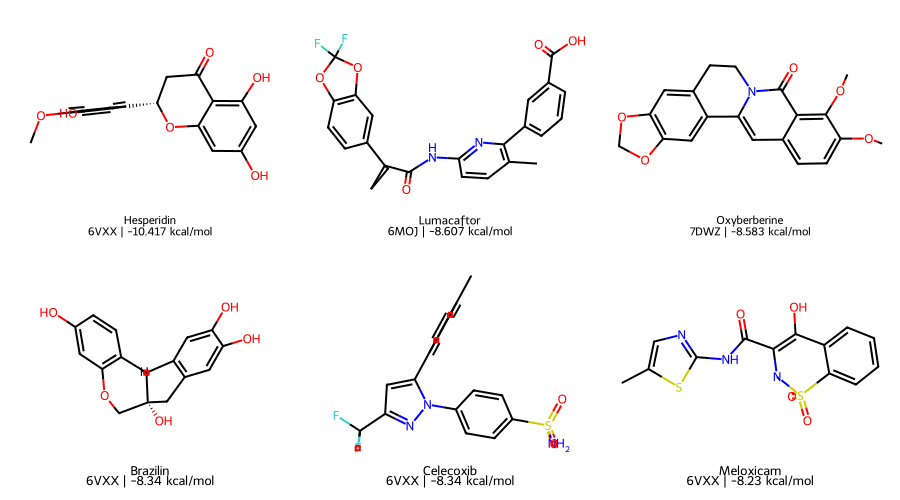

✅ Saved as top_inhibitors.png


In [8]:
top6  = df_props[df_props['Lipinski_Pass']==True].sort_values('Binding_Energy').head(6)
mols, labels = [], []
for _, r in top6.iterrows():
    mol = load_mol(name_to_sdf.get(r['Ligand'].strip()))
    if mol:
        mols.append(mol)
        labels.append(f"{r['Ligand']}\n{r['Protein']} | {r['Binding_Energy']} kcal/mol")

if mols:
    img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300,250), legends=labels, returnPNG=False)
    img.save('top_inhibitors.png')
    display(img)
    print('✅ Saved as top_inhibitors.png')

## Step 9 — Save Results & Final Summary

In [9]:
df_props.to_csv('full_analysis.csv', index=False)
df_props[df_props['Lipinski_Pass']==True].sort_values('Binding_Energy').to_csv('top_drug_like_hits.csv', index=False)

print('✅ Saved: full_analysis.csv + top_drug_like_hits.csv')
print()
print('='*55)
print('📊 FINAL DISSERTATION SUMMARY')
print('='*55)
print(f'Compounds analysed : {df_props["Ligand"].nunique()}')
print(f'Protein targets    : 6M0J | 6VXX | 7DWZ')
print(f'Total entries      : {len(df_props)}')
print(f'Lipinski pass      : {int(df_props["Lipinski_Pass"].sum())}')
print(f'Best binding energy: {df_props["Binding_Energy"].min()} kcal/mol')
print(f'Best compound      : {df_props.loc[df_props["Binding_Energy"].idxmin(),"Ligand"]}')
print(f'Best target        : {df_props.loc[df_props["Binding_Energy"].idxmin(),"Protein"]}')
print()
print('Top hit per protein:')
for p in sorted(df_props['Protein'].unique()):
    s = df_props[df_props['Protein']==p]
    b = s.loc[s['Binding_Energy'].idxmin()]
    print(f'  {p} → {b["Ligand"]} ({b["Binding_Energy"]} kcal/mol)')

✅ Saved: full_analysis.csv + top_drug_like_hits.csv

📊 FINAL DISSERTATION SUMMARY
Compounds analysed : 82
Protein targets    : 6M0J | 6VXX | 7DWZ
Total entries      : 82
Lipinski pass      : 55
Best binding energy: -12.298 kcal/mol
Best compound      : Digoxin
Best target        : 7DWZ

Top hit per protein:
  6MOJ → Lumacaftor (-8.607 kcal/mol)
  6VXX → Hesperidin (-10.417 kcal/mol)
  7DWZ → Digoxin (-12.298 kcal/mol)
